# PSW Graduate Tax Contribution: A Data-Driven Analysis

I arrived in the UK in January 2023 to study MSc Data Analytics at Aston University, Birmingham. After graduating in March 2024, I moved to Hull where living costs were lower. I started working at Cranswick Convenience Foods in July 2024, then moved to Copernus Fresh Fish as Team Leader in April 2025.

**This notebook uses my real payslip data to answer: how much have I actually contributed to the UK, and is what the government charges me fair?**

All figures are from confirmed payslip year-to-date totals and pension provider portals.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

GBP = lambda x: f'£{x:,.0f}'

## 1. My Payslip Data

Extracted from year-to-date totals on my final payslips from each employer.

In [2]:
# My employment data from payslips
employment = pd.DataFrame({
    'Employer': ['Cranswick Convenience Foods', 'Copernus Ltd'],
    'Role': ['Production Operative', 'Team Leader'],
    'Period': ['Jul 2024 - Apr 2025', 'Apr 2025 - Mar 2026'],
    'Months': [9, 12],
    'Hourly_Rate': [12.11, 14.00],
    'Gross_Earnings': [11605.28, 30534.46],
    'PAYE_Tax': [0.00, 3794.20],
    'Employee_NI': [485.34, 1513.47],
    'Employee_Pension': [214.28, 1010.60],
    'Employer_NI': [1500, 3888.91],
    'Employer_Pension': [130, 606.35],
    'Pension_Pot_Actual': [504.31, 1975.39]
})

employment['Total_Tax_NI'] = employment['PAYE_Tax'] + employment['Employee_NI']
employment['Net_Pay_Est'] = employment['Gross_Earnings'] - employment['PAYE_Tax'] - employment['Employee_NI'] - employment['Employee_Pension']

print("=" * 60)
print("PAWAN'S EMPLOYMENT SUMMARY")
print("=" * 60)
for _, row in employment.iterrows():
    print(f"\n{row['Employer']} ({row['Period']})")
    print(f"  Role: {row['Role']}")
    print(f"  Rate: £{row['Hourly_Rate']}/hr")
    print(f"  Gross: {GBP(row['Gross_Earnings'])}")
    print(f"  Tax: {GBP(row['PAYE_Tax'])} | NI: {GBP(row['Employee_NI'])} | Pension: {GBP(row['Employee_Pension'])}")
    print(f"  Pension pot (actual): {GBP(row['Pension_Pot_Actual'])}")

print(f"\n{'=' * 60}")
print(f"TOTAL GROSS EARNINGS: {GBP(employment['Gross_Earnings'].sum())}")
print(f"TOTAL TAX + NI PAID:  {GBP(employment['Total_Tax_NI'].sum())}")
print(f"TOTAL PENSION POT:    {GBP(employment['Pension_Pot_Actual'].sum())}")

PAWAN'S EMPLOYMENT SUMMARY

Cranswick Convenience Foods (Jul 2024 - Apr 2025)
  Role: Production Operative
  Rate: £12.11/hr
  Gross: £11,605
  Tax: £0 | NI: £485 | Pension: £214
  Pension pot (actual): £504

Copernus Ltd (Apr 2025 - Mar 2026)
  Role: Team Leader
  Rate: £14.0/hr
  Gross: £30,534
  Tax: £3,794 | NI: £1,513 | Pension: £1,011
  Pension pot (actual): £1,975

TOTAL GROSS EARNINGS: £42,140
TOTAL TAX + NI PAID:  £5,793
TOTAL PENSION POT:    £2,480


## 2. Pawan's Tax & NI Contribution

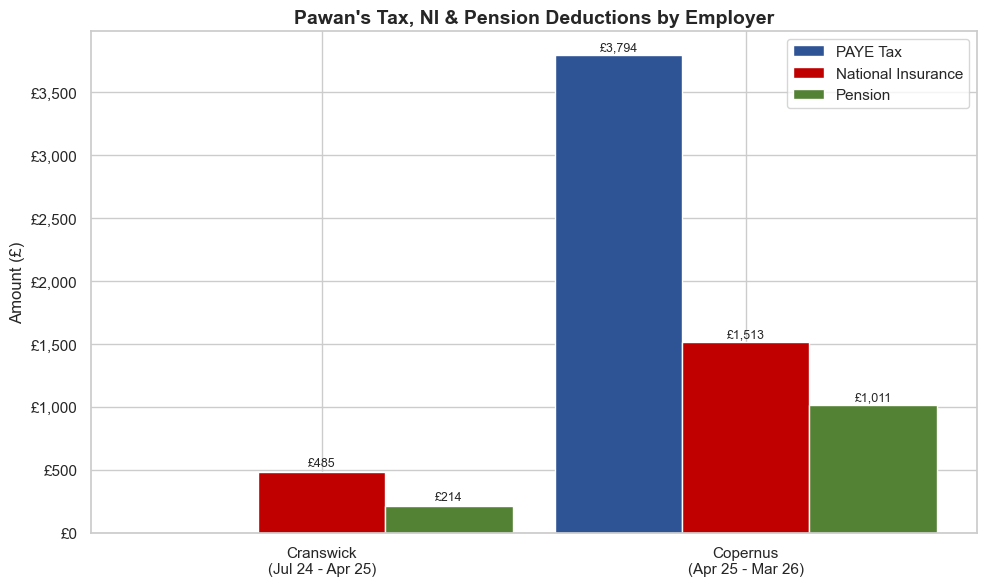

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(employment))
width = 0.3

bars1 = ax.bar([i - width for i in x], employment['PAYE_Tax'], width, label='PAYE Tax', color='#2F5496')
bars2 = ax.bar(x, employment['Employee_NI'], width, label='National Insurance', color='#C00000')
bars3 = ax.bar([i + width for i in x], employment['Employee_Pension'], width, label='Pension', color='#548235')

ax.set_xticks(x)
ax.set_xticklabels(['Cranswick\n(Jul 24 - Apr 25)', 'Copernus\n(Apr 25 - Mar 26)'])
ax.set_ylabel('Amount (£)')
ax.set_title("Pawan's Tax, NI & Pension Deductions by Employer", fontsize=14, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('£{x:,.0f}'))

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2., h + 20, f'£{h:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('charts/01_tax_ni_by_employer.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. What I Paid vs What a UK Citizen Pays â€” Same Job

A UK citizen doing the same work at the same pay rate would pay the same tax and NI. But I paid thousands more in visa fees, IHS, and international tuition.

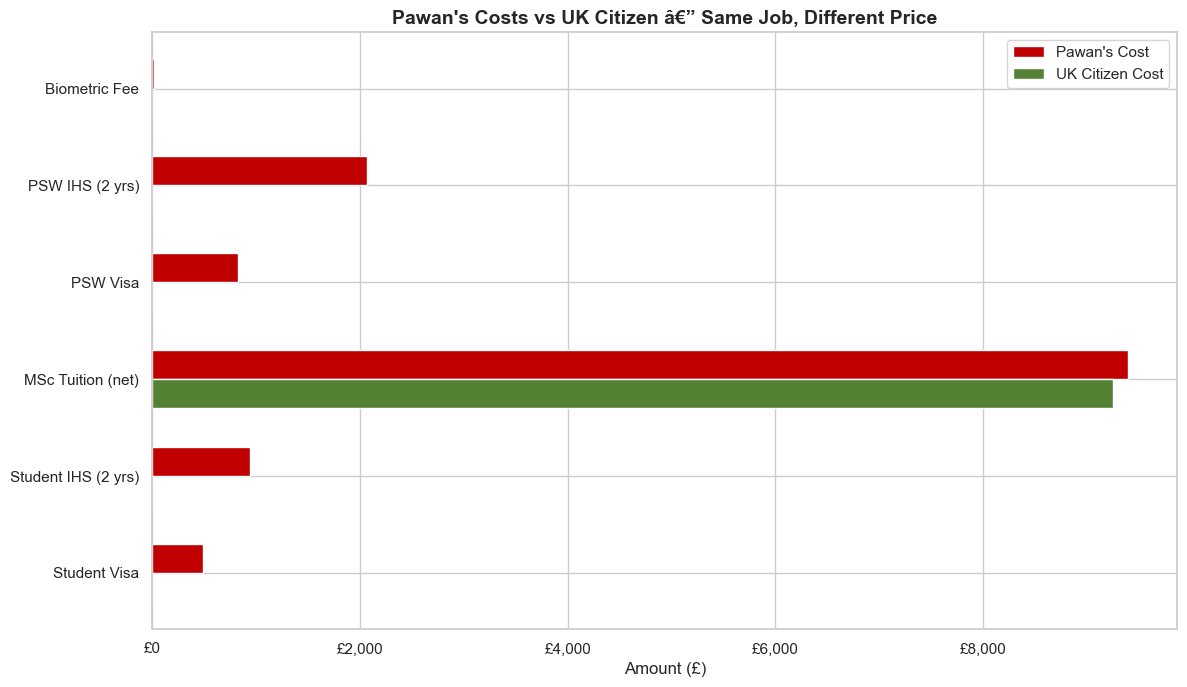


TOTAL EXTRA I PAID vs UK CITIZEN: £4,491


In [4]:
# Immigration costs comparison
comparison = pd.DataFrame({
    'Item': ['Student Visa', 'Student IHS (2 yrs)', 'MSc Tuition (net)', 'PSW Visa', 'PSW IHS (2 yrs)', 'Biometric Fee',
             'PAYE Tax', 'National Insurance', 'VAT (est.)', 'Council Tax (est.)'],
    'Pawan': [490, 940, 9400, 822, 2070, 19.20, 3794.20, 1998.81, 2000, 1200],
    'UK_Citizen': [0, 0, 9250, 0, 0, 0, 3794.20, 1998.81, 2000, 1200]
})
comparison['Extra_Pawan_Paid'] = comparison['Pawan'] - comparison['UK_Citizen']

# Immigration-only costs
immigration = comparison[comparison['Extra_Pawan_Paid'] > 0].copy()

fig, ax = plt.subplots(figsize=(12, 7))
y = range(len(immigration))
bars_p = ax.barh([i + 0.15 for i in y], immigration['Pawan'], 0.3, label="Pawan's Cost", color='#C00000')
bars_u = ax.barh([i - 0.15 for i in y], immigration['UK_Citizen'], 0.3, label='UK Citizen Cost', color='#548235')

ax.set_yticks(y)
ax.set_yticklabels(immigration['Item'])
ax.set_xlabel('Amount (£)')
ax.set_title("Pawan's Costs vs UK Citizen â€” Same Job, Different Price", fontsize=14, fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('£{x:,.0f}'))

plt.tight_layout()
plt.savefig('charts/02_pawan_vs_uk_citizen.png', dpi=150, bbox_inches='tight')
plt.show()

total_extra = immigration['Extra_Pawan_Paid'].sum()
print(f"\nTOTAL EXTRA I PAID vs UK CITIZEN: {GBP(total_extra)}")

## 4. The NHS Double Charge

I pay National Insurance â€” which funds the NHS. I also pay the Immigration Health Surcharge â€” which also funds the NHS. I'm paying for the same thing twice.

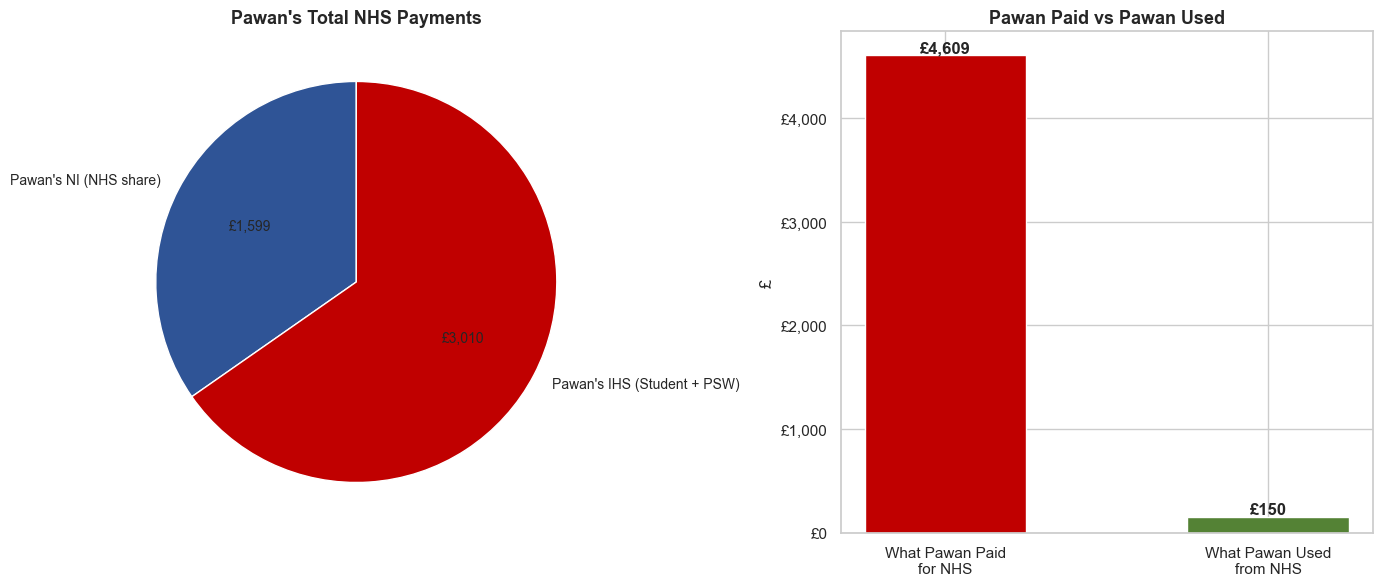

I paid £4,609 for NHS access.
I used £150 of NHS services (1 A&E visit â€” waited 4 hours, paid for my own medicine).
A UK citizen on the same salary paid £1,599 for the same access.
I overpaid by £3,010 (the IHS â€” a duplicate charge on top of NI).


In [5]:
ni_total = employment['Employee_NI'].sum()
ni_nhs_share = ni_total * 0.80  # ~80% of NI goes to NHS
ihs_total = 2070 + 940  # PSW IHS + Student IHS
nhs_used = 150  # one A&E visit, waited 4 hours, paid for medicine

nhs_data = pd.DataFrame({
    'Source': ["Pawan's NI (NHS share)", "Pawan's IHS (Student + PSW)"],
    'Amount': [ni_nhs_share, ihs_total]
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors = ['#2F5496', '#C00000']
wedges, texts, autotexts = ax1.pie(nhs_data['Amount'], labels=nhs_data['Source'],
                                     autopct=lambda p: f'£{p*nhs_data["Amount"].sum()/100:,.0f}',
                                     colors=colors, startangle=90, textprops={'fontsize': 10})
ax1.set_title("Pawan's Total NHS Payments", fontsize=13, fontweight='bold')

# Bar: paid vs used
paid_vs_used = pd.DataFrame({
    'Category': ["What Pawan Paid\nfor NHS", "What Pawan Used\nfrom NHS"],
    'Amount': [ni_nhs_share + ihs_total, nhs_used]
})
bars = ax2.bar(paid_vs_used['Category'], paid_vs_used['Amount'], color=['#C00000', '#548235'], width=0.5)
ax2.set_ylabel('£')
ax2.set_title('Pawan Paid vs Pawan Used', fontsize=13, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.StrMethodFormatter('£{x:,.0f}'))
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
             f'£{bar.get_height():,.0f}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('charts/03_nhs_double_charge.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"I paid {GBP(ni_nhs_share + ihs_total)} for NHS access.")
print(f"I used {GBP(nhs_used)} of NHS services (1 A&E visit â€” waited 4 hours, paid for my own medicine).")
print(f"A UK citizen on the same salary paid {GBP(ni_nhs_share)} for the same access.")
print(f"I overpaid by {GBP(ihs_total)} (the IHS â€” a duplicate charge on top of NI).")

## 5. My Net Contribution to the UK

Everything I put into the UK economy vs everything I took out.

In [6]:
put_in = pd.DataFrame({
    'Item': ['PAYE Income Tax', 'My National Insurance', 'Employer NI (exists because I work)',
             'My Pension Contributions', 'Employer Pension', 'Student Visa + IHS',
             'PSW Visa + IHS', 'MSc Tuition (net of scholarship)',
             'VAT on spending (estimated)', 'Council Tax (through rent, est.)'],
    'Amount': [3794.20, 1998.81, 5389, 1224.88, 736, 1430, 2892, 9400, 2000, 1200]
})

took_out = pd.DataFrame({
    'Item': ['NHS (1 A&E visit â€” paid for own medicine)', 'Benefits claimed', 'Social housing',
             'State education', 'Legal aid'],
    'Amount': [150, 0, 0, 0, 0]
})

total_in = put_in['Amount'].sum()
total_out = took_out['Amount'].sum()
net = total_in - total_out

print("WHAT I PUT IN:")
print("=" * 50)
for _, row in put_in.iterrows():
    print(f"  {row['Item']:.<45} {GBP(row['Amount'])}")
print(f"  {'TOTAL':.<45} {GBP(total_in)}")

print(f"\nWHAT I TOOK OUT:")
print("=" * 50)
for _, row in took_out.iterrows():
    print(f"  {row['Item']:.<45} {GBP(row['Amount'])}")
print(f"  {'TOTAL':.<45} {GBP(total_out)}")

print(f"\n{'=' * 50}")
print(f"  PAWAN'S NET CONTRIBUTION TO THE UK: {GBP(net)}")
print(f"{'=' * 50}")

WHAT I PUT IN:
  PAYE Income Tax.............................. £3,794
  My National Insurance........................ £1,999
  Employer NI (exists because I work).......... £5,389
  My Pension Contributions..................... £1,225
  Employer Pension............................. £736
  Student Visa + IHS........................... £1,430
  PSW Visa + IHS............................... £2,892
  MSc Tuition (net of scholarship)............. £9,400
  VAT on spending (estimated).................. £2,000
  Council Tax (through rent, est.)............. £1,200
  TOTAL........................................ £30,065

WHAT I TOOK OUT:
  NHS (1 A&E visit â€” paid for own medicine).. £150
  Benefits claimed............................. £0
  Social housing............................... £0
  State education.............................. £0
  Legal aid.................................... £0
  TOTAL........................................ £150

  PAWAN'S NET CONTRIBUTION TO THE UK: £29,915


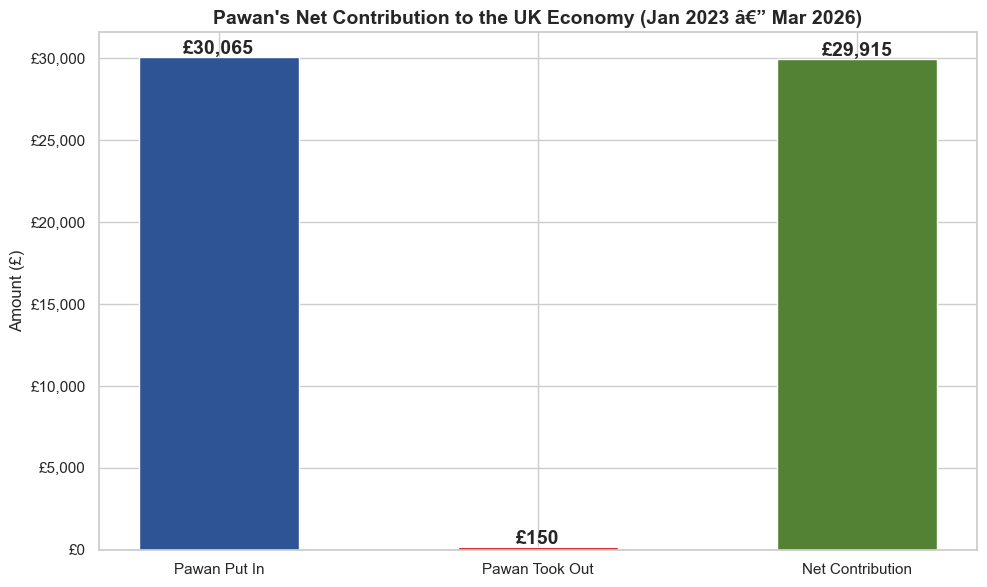

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
categories = ["Pawan Put In", "Pawan Took Out", "Net Contribution"]
values = [total_in, total_out, net]
colors = ['#2F5496', '#C00000', '#548235']

bars = ax.bar(categories, values, color=colors, width=0.5)
ax.set_ylabel('Amount (£)')
ax.set_title("Pawan's Net Contribution to the UK Economy (Jan 2023 â€” Mar 2026)", fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('£{x:,.0f}'))

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
            f'£{val:,.0f}', ha='center', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('charts/04_net_contribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. How Do I Compare to the Average UK Taxpayer?

Using HMRC and ONS data to put my contribution in context.

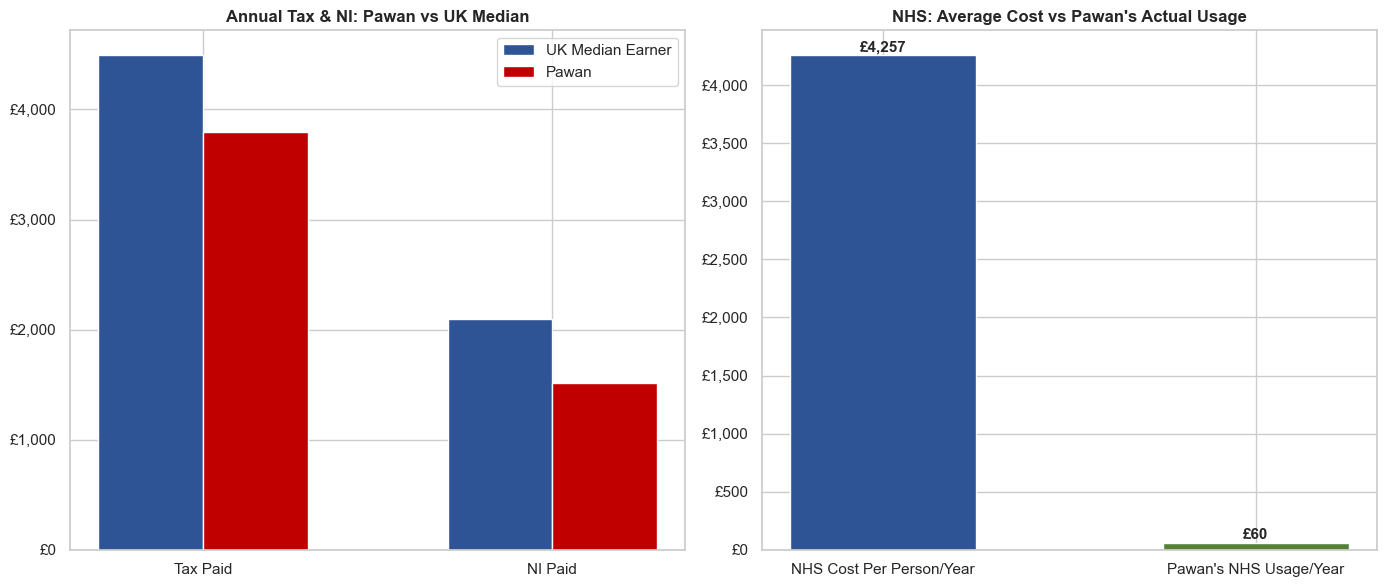

The NHS costs £4,257 per person per year on average.
I cost the NHS £60 per year over 2.5 years.
I paid £1,844 per year towards the NHS.
That's 31x what I actually cost.


In [8]:
# ONS/HMRC reference data (2024/25)
avg_uk = {
    'Median UK salary': 34963,
    'Average tax paid (median earner)': 4493,
    'Average NI paid (median earner)': 2094,
    'NHS cost per person per year': 4257,
    'Average benefits received per household': 8700,
}

pawan = {
    'My annual salary (Copernus)': 30534,
    'My tax paid (Copernus year)': 3794,
    'My NI paid (Copernus year)': 1513,
    'NHS cost I generated': 150,
    'Benefits I received': 0,
}

comp_df = pd.DataFrame({
    'Metric': list(avg_uk.keys()),
    'UK Average': list(avg_uk.values()),
    'Pawan': list(pawan.values())
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Tax comparison
tax_comp = pd.DataFrame({
    'Category': ['Tax Paid', 'NI Paid'],
    'UK Median Earner': [4493, 2094],
    'Pawan': [3794, 1513]
})
x = range(len(tax_comp))
axes[0].bar([i-0.15 for i in x], tax_comp['UK Median Earner'], 0.3, label='UK Median Earner', color='#2F5496')
axes[0].bar([i+0.15 for i in x], tax_comp['Pawan'], 0.3, label='Pawan', color='#C00000')
axes[0].set_xticks(x); axes[0].set_xticklabels(tax_comp['Category'])
axes[0].set_title('Annual Tax & NI: Pawan vs UK Median', fontweight='bold')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('£{x:,.0f}'))

# NHS cost vs usage
nhs_comp = pd.DataFrame({
    'Category': ['NHS Cost Per Person/Year', "Pawan's NHS Usage/Year"],
    'Amount': [4257, 150/2.5]  # Pawan's usage over 2.5 years
})
bars2 = axes[1].bar(nhs_comp['Category'], nhs_comp['Amount'], color=['#2F5496', '#548235'], width=0.5)
axes[1].set_title('NHS: Average Cost vs Pawan\'s Actual Usage', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('£{x:,.0f}'))
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
                 f'£{bar.get_height():,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/05_vs_average_uk.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"The NHS costs £4,257 per person per year on average.")
print(f"I cost the NHS £{150/2.5:,.0f} per year over 2.5 years.")
print(f"I paid £{(ni_nhs_share + ihs_total)/2.5:,.0f} per year towards the NHS.")
print(f"That's {(ni_nhs_share + ihs_total)/2.5 / (150/2.5):,.0f}x what I actually cost.")

## 7. Pawan's Pension

Confirmed balances from provider portals as of March 2026.

PAWAN'S PENSION SUMMARY

Legal & General (Cranswick)
  My contributions:       £214
  Employer contributions: £130
  Investment growth:      £160
  ACTUAL POT VALUE:       £504

Workplace Pension (Copernus)
  My contributions:       £1,011
  Employer contributions: £606
  Investment growth:      £358
  ACTUAL POT VALUE:       £1,975

TOTAL PENSION POT: £2,480

Notes:
  - Cannot access until age 57
  - Can transfer to QROPS if I leave the UK
  - Both are salary sacrifice (pre-tax)


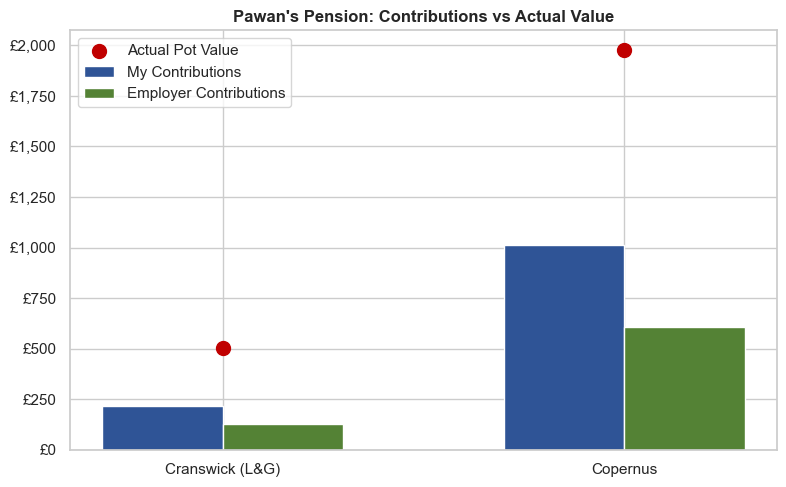

In [9]:
pension = pd.DataFrame({
    'Provider': ['Legal & General (Cranswick)', 'Workplace Pension (Copernus)'],
    'My_Contributions': [214.28, 1010.60],
    'Employer_Contributions': [130, 606.35],
    'Actual_Pot_Value': [504.31, 1975.39]
})
pension['Total_Contributed'] = pension['My_Contributions'] + pension['Employer_Contributions']
pension['Investment_Growth'] = pension['Actual_Pot_Value'] - pension['Total_Contributed']

print("PAWAN'S PENSION SUMMARY")
print("=" * 60)
for _, row in pension.iterrows():
    print(f"\n{row['Provider']}")
    print(f"  My contributions:       {GBP(row['My_Contributions'])}")
    print(f"  Employer contributions: {GBP(row['Employer_Contributions'])}")
    print(f"  Investment growth:      {GBP(row['Investment_Growth'])}")
    print(f"  ACTUAL POT VALUE:       {GBP(row['Actual_Pot_Value'])}")

print(f"\n{'=' * 60}")
print(f"TOTAL PENSION POT: {GBP(pension['Actual_Pot_Value'].sum())}")
print(f"\nNotes:")
print(f"  - Cannot access until age 57")
print(f"  - Can transfer to QROPS if I leave the UK")
print(f"  - Both are salary sacrifice (pre-tax)")

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(pension))
ax.bar([i-0.15 for i in x], pension['My_Contributions'], 0.3, label='My Contributions', color='#2F5496')
ax.bar([i+0.15 for i in x], pension['Employer_Contributions'], 0.3, label='Employer Contributions', color='#548235')
ax.scatter(x, pension['Actual_Pot_Value'], color='#C00000', s=100, zorder=5, label='Actual Pot Value')
ax.set_xticks(x); ax.set_xticklabels(['Cranswick (L&G)', 'Copernus'])
ax.set_title("Pawan's Pension: Contributions vs Actual Value", fontweight='bold')
ax.legend(); ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('£{x:,.0f}'))
plt.tight_layout()
plt.savefig('charts/06_pension.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Generate Excel Report

Exporting the complete analysis to Excel.

In [10]:
with pd.ExcelWriter('UK_Immigration_Tax_Fairness.xlsx', engine='openpyxl') as writer:
    employment.to_excel(writer, sheet_name='Employment Data', index=False)
    comparison.to_excel(writer, sheet_name='Pawan vs UK Citizen', index=False)
    put_in.to_excel(writer, sheet_name='Net Contribution - In', index=False)
    took_out.to_excel(writer, sheet_name='Net Contribution - Out', index=False)
    pension.to_excel(writer, sheet_name='Pension', index=False)
    
    # Summary sheet
    summary = pd.DataFrame({
        'Metric': ['Total Gross Earnings', 'Total Tax + NI Paid', 'Total Immigration Costs',
                   'Total Put Into UK Economy', 'Total Taken From UK', 'NET CONTRIBUTION',
                   'Pension Pot', 'NHS Paid', 'NHS Used', 'PSW Expiry'],
        'Value': [f'{GBP(employment["Gross_Earnings"].sum())}',
                  f'{GBP(employment["Total_Tax_NI"].sum())}',
                  f'{GBP(total_extra)}',
                  f'{GBP(total_in)}',
                  f'{GBP(total_out)}',
                  f'{GBP(net)}',
                  f'{GBP(pension["Actual_Pot_Value"].sum())}',
                  f'{GBP(ni_nhs_share + ihs_total)}',
                  f'{GBP(nhs_used)}',
                  'May/June 2026']
    })
    summary.to_excel(writer, sheet_name='Summary', index=False)

print('Excel report saved: UK_Immigration_Tax_Fairness.xlsx')

Excel report saved: UK_Immigration_Tax_Fairness.xlsx


## 9. Conclusion

In 2.5 years of living in the UK, I contributed approximately **£30,000** to the UK economy through taxes, NI, visa fees, university tuition, and indirect taxes. I consumed approximately **£150** in public services.

Despite this:
- I was charged **£2,892 extra** compared to a UK citizen for the same job
- I pay for the **NHS twice** (NI + IHS)
- I have **No Recourse to Public Funds** â€” I cannot claim benefits
- Most data analyst jobs **rejected me because of my visa**
- My visa **expires in mid-2026** â€” if I can't find a sponsor, I leave

I built this analysis because the numbers matter. Immigration policy should be based on data, not assumptions. The data shows I am a significant net contributor to the UK.